# Total Available Energy Analysis

The GNN predicts EE domestic **production** (MW). This notebook converts those predictions into **total available energy** by adding actual Elering cross-border flows for the connected scenario.

| Scenario | Production | Imports | What it shows |
|----------|-----------|---------|---------------|
| **S0: Connected** | GNN (full grid) | Actual Elering Jan 2026 | Baseline — what Jan 2026 looked like |
| **S0: Isolated (no response)** | Same as S0 connected | 0 | Immediate shock — cables cut, plants haven't responded yet |
| **S1: Isolated** | GNN (isolation mode) | 0 | Power plants ramp up to compensate |
| **S2: Isolated + 323 MW wind** | GNN isolation + wind A | 0 | Established planning-stage farms |
| **S3: Isolated + 887 MW wind** | GNN isolation + wind B | 0 | Full pipeline farms |

**Key gaps in the report:**
- S0 connected → S0 isolated = **import dependency** (how much Estonia relies on Nordic grid)
- S0 isolated → S1 isolated = **value of plant dispatch response**
- S1 isolated → S2/S3 = **value of wind capacity**

In [8]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Paths — notebook lives in project/, data one level up
_NB_DIR  = os.getcwd()
_DATA    = os.path.join(_NB_DIR, "..", "data")
_FIGURES = os.path.join(_NB_DIR, "..", "figures")
os.makedirs(_FIGURES, exist_ok=True)

## 1. Load GNN production scenarios

In [9]:
supply_csv = os.path.join(_DATA, "gnn_supply_scenarios_jan2026.csv")
supply = pd.read_csv(supply_csv, parse_dates=["timestamp"], index_col="timestamp")
if supply.index.tz is None:
    supply.index = supply.index.tz_localize("UTC")

print(f"GNN supply scenarios: {len(supply)} hours")
supply.head()

GNN supply scenarios: 721 hours


,supply_s1_p10,supply_s1_p50,supply_s1_p90,supply_s2_p10,supply_s2_p50,supply_s2_p90,supply_s3_p10,supply_s3_p50,supply_s3_p90,supply_s4_p10,supply_s4_p50,supply_s4_p90
timestamp,,,,,,,,,,,,
2025-12-31 23:00:00+00:00,203.91954,308.58167,465.86560,204.61324,310.47714,468.82623,204.61324,310.47714,468.82623,204.61324,310.47714,468.82623
2026-01-01 00:00:00+00:00,215.17056,320.34738,479.82092,215.45326,321.81717,482.82860,214.09802,320.68274,482.18414,212.61105,319.42642,481.44943
2026-01-01 01:00:00+00:00,208.31447,316.78314,477.22232,209.09276,317.26767,479.66690,204.87119,314.45610,477.34363,198.87932,311.29260,474.79355
2026-01-01 02:00:00+00:00,221.36224,334.41983,495.86148,222.38101,334.52167,497.87604,212.68213,329.32983,493.32242,198.82080,321.23352,486.39210
2026-01-01 03:00:00+00:00,230.97656,350.81310,512.97010,232.89001,351.12988,515.50520,213.65213,339.92523,505.68878,189.87643,326.09100,490.72052


## 2. Load actual Jan 2026 cross-border flows (Elering cache)

In [10]:
cache_file = os.path.join(_NB_DIR, "..", "data_cache.pkl")
with open(cache_file, "rb") as f:
    _, df_flows, _, _ = pickle.load(f)

flows_h = df_flows.resample("h").mean().fillna(0)
if flows_h.index.tz is None:
    flows_h.index = flows_h.index.tz_localize("UTC")

jan26 = (flows_h.index.year == 2026) & (flows_h.index.month == 1)
flows_jan26 = flows_h[jan26]
print(f"Loaded {jan26.sum()} Jan 2026 hours from Elering cache")

Loaded 744 Jan 2026 hours from Elering cache


## 3. Compute net imports

Elering sign convention: **negative flow = EE importing** from that country.  
`net_import = −flow(EE→FI) − flow(EE→LV)`  
RU flows ≈ 0 since April 2024 Baltic synchronisation with Nordic grid.

In [11]:
net_imports = (
    -flows_jan26[("ee", "fi")]
    - flows_jan26[("ee", "lv")]
).rename("net_imports_mw")

net_imports = net_imports.reindex(supply.index, method="nearest").fillna(0)

print(f"Net imports Jan 2026:")
print(f"  mean : {net_imports.mean():.0f} MW  (positive = importing)")
print(f"  min  : {net_imports.min():.0f} MW")
print(f"  max  : {net_imports.max():.0f} MW")

Net imports Jan 2026:
  mean : 583 MW  (positive = importing)
  min  : 122 MW
  max  : 1031 MW


## 4. Build all 5 scenarios

In [12]:
# S0: Connected — GNN production + actual net imports
total_s0_p10 = supply["supply_s1_p10"].values + net_imports.values
total_s0_p50 = supply["supply_s1_p50"].values + net_imports.values
total_s0_p90 = supply["supply_s1_p90"].values + net_imports.values

# S0 isolated (no response) — same production as S0 connected, but imports = 0
# Represents the immediate shock before power plants respond
s0_iso_p10 = supply["supply_s1_p10"].values
s0_iso_p50 = supply["supply_s1_p50"].values
s0_iso_p90 = supply["supply_s1_p90"].values

# S1: Isolated — GNN isolation prediction (power plants ramp up), no imports
total_s1_p10 = supply["supply_s2_p10"].values
total_s1_p50 = supply["supply_s2_p50"].values
total_s1_p90 = supply["supply_s2_p90"].values

# S2: Isolated + 323 MW wind (Scenario A — established plans)
total_s2_p10 = supply["supply_s3_p10"].values
total_s2_p50 = supply["supply_s3_p50"].values
total_s2_p90 = supply["supply_s3_p90"].values

# S3: Isolated + 887 MW wind (Scenario B — full pipeline)
total_s3_p10 = supply["supply_s4_p10"].values
total_s3_p50 = supply["supply_s4_p50"].values
total_s3_p90 = supply["supply_s4_p90"].values

idx = supply.index.to_numpy()

print("Mean available energy by scenario:")
for label, arr in [
    ("S0 Connected          ", total_s0_p50),
    ("S0 Isolated (no resp) ", s0_iso_p50),
    ("S1 Isolated           ", total_s1_p50),
    ("S2 Isolated + 323 MW  ", total_s2_p50),
    ("S3 Isolated + 887 MW  ", total_s3_p50),
]:
    print(f"  {label}: {arr.mean():.0f} MW")

Mean available energy by scenario:
  S0 Connected          : 1314 MW
  S0 Isolated (no resp) : 731 MW
  S1 Isolated           : 735 MW
  S2 Isolated + 323 MW  : 710 MW
  S3 Isolated + 887 MW  : 686 MW


## 5. Plots

**Left column** — domestic production only (GNN output)  
**Right column** — total available energy (production + imports for S0)

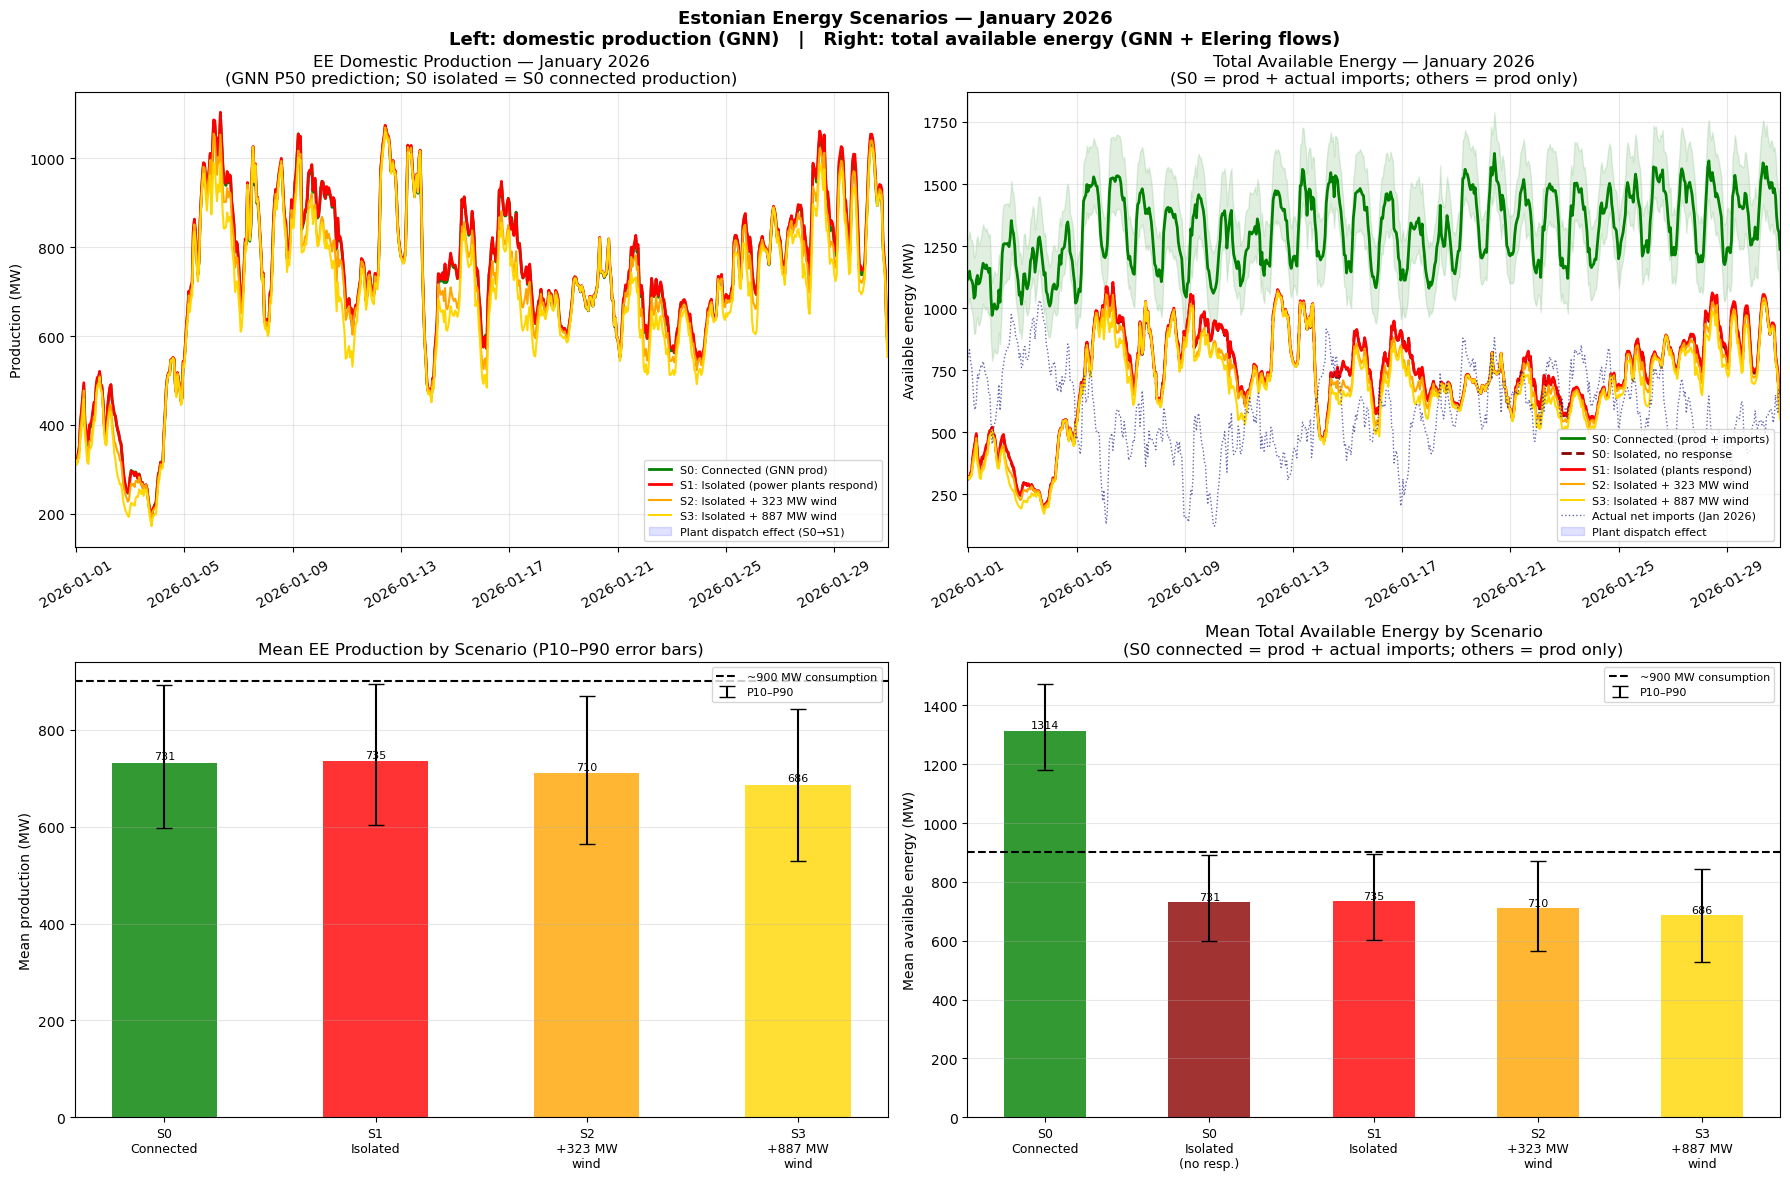

Saved → /Users/ursulailves/Desktop/DTU-DEV/spring26/advancedBA/project_BA/Advanced_BA/project/../figures/available_energy_scenarios.png


In [13]:
CONSUMPTION_REF = 900  # typical Jan consumption MW

# Colors
C_S0      = "green"
C_S0_ISO  = "darkred"
C_S1      = "red"
C_S2      = "orange"
C_S3      = "gold"

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Top-left: GNN production time series (what the model predicts) ────────────
ax = axes[0, 0]
ax.plot(idx, supply["supply_s1_p50"].values, lw=2,   color=C_S0,     label="S0: Connected (GNN prod)")
ax.plot(idx, supply["supply_s2_p50"].values, lw=2,   color=C_S1,     label="S1: Isolated (power plants respond)")
ax.plot(idx, supply["supply_s3_p50"].values, lw=1.5, color=C_S2,     label="S2: Isolated + 323 MW wind")
ax.plot(idx, supply["supply_s4_p50"].values, lw=1.5, color=C_S3,     label="S3: Isolated + 887 MW wind")
ax.fill_between(idx, supply["supply_s1_p50"].values, supply["supply_s2_p50"].values,
                alpha=0.12, color="blue", label="Plant dispatch effect (S0→S1)")
ax.set_title("EE Domestic Production — January 2026\n(GNN P50 prediction; S0 isolated = S0 connected production)")
ax.set_ylabel("Production (MW)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.tick_params(axis="x", rotation=30)
ax.set_xlim(idx.min(), idx.max())

# ── Top-right: Total available energy (adds imports for S0) ───────────────────
ax = axes[0, 1]
ax.fill_between(idx, total_s0_p10, total_s0_p90, alpha=0.12, color=C_S0)
ax.plot(idx, total_s0_p50,  lw=2,   color=C_S0,    label="S0: Connected (prod + imports)")
ax.plot(idx, s0_iso_p50,    lw=2,   color=C_S0_ISO, linestyle="--", label="S0: Isolated, no response")
ax.plot(idx, total_s1_p50,  lw=2,   color=C_S1,    label="S1: Isolated (plants respond)")
ax.plot(idx, total_s2_p50,  lw=1.5, color=C_S2,    label="S2: Isolated + 323 MW wind")
ax.plot(idx, total_s3_p50,  lw=1.5, color=C_S3,    label="S3: Isolated + 887 MW wind")
ax.plot(idx, net_imports.values, lw=1, color="navy", linestyle=":", alpha=0.6,
        label="Actual net imports (Jan 2026)")
ax.fill_between(idx, s0_iso_p50, total_s1_p50,
                alpha=0.12, color="blue", label="Plant dispatch effect")
ax.set_title("Total Available Energy — January 2026\n(S0 = prod + actual imports; others = prod only)")
ax.set_ylabel("Available energy (MW)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.tick_params(axis="x", rotation=30)
ax.set_xlim(idx.min(), idx.max())

# ── Bottom-left: Bar — mean production ───────────────────────────────────────
ax = axes[1, 0]
s_labels_prod = ["S0\nConnected", "S1\nIsolated", "S2\n+323 MW\nwind", "S3\n+887 MW\nwind"]
s_colors_prod = [C_S0, C_S1, C_S2, C_S3]
prod_keys = ["s1", "s2", "s3", "s4"]
prod_p50 = [supply[f"supply_{k}_p50"].mean() for k in prod_keys]
prod_p10 = [supply[f"supply_{k}_p10"].mean() for k in prod_keys]
prod_p90 = [supply[f"supply_{k}_p90"].mean() for k in prod_keys]
err_lo = [max(0.0, p50-p10) for p50,p10 in zip(prod_p50, prod_p10)]
err_hi = [max(0.0, p90-p50) for p50,p90 in zip(prod_p50, prod_p90)]
x4 = np.arange(4)
bars = ax.bar(x4, prod_p50, 0.5, color=s_colors_prod, alpha=0.8)
ax.errorbar(x4, prod_p50, yerr=[err_lo, err_hi], fmt="none", color="black", capsize=6, lw=1.5, label="P10–P90")
for bar, val in zip(bars, prod_p50):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8, f"{val:.0f}", ha="center", fontsize=8)
ax.axhline(CONSUMPTION_REF, color="black", lw=1.5, linestyle="--", label=f"~{CONSUMPTION_REF} MW consumption")
ax.set_xticks(x4); ax.set_xticklabels(s_labels_prod, fontsize=9)
ax.set_ylabel("Mean production (MW)")
ax.set_title("Mean EE Production by Scenario (P10–P90 error bars)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

# ── Bottom-right: Bar — mean total available energy (5 scenarios) ─────────────
ax = axes[1, 1]
s_labels_tot = ["S0\nConnected", "S0\nIsolated\n(no resp.)", "S1\nIsolated", "S2\n+323 MW\nwind", "S3\n+887 MW\nwind"]
s_colors_tot = [C_S0, C_S0_ISO, C_S1, C_S2, C_S3]
tot_p50 = [total_s0_p50.mean(), s0_iso_p50.mean(), total_s1_p50.mean(), total_s2_p50.mean(), total_s3_p50.mean()]
tot_p10 = [total_s0_p10.mean(), s0_iso_p10.mean(), total_s1_p10.mean(), total_s2_p10.mean(), total_s3_p10.mean()]
tot_p90 = [total_s0_p90.mean(), s0_iso_p90.mean(), total_s1_p90.mean(), total_s2_p90.mean(), total_s3_p90.mean()]
err_lo_t = [max(0.0, p50-p10) for p50,p10 in zip(tot_p50, tot_p10)]
err_hi_t = [max(0.0, p90-p50) for p50,p90 in zip(tot_p50, tot_p90)]
x5 = np.arange(5)
bars = ax.bar(x5, tot_p50, 0.5, color=s_colors_tot, alpha=0.8)
ax.errorbar(x5, tot_p50, yerr=[err_lo_t, err_hi_t], fmt="none", color="black", capsize=6, lw=1.5, label="P10–P90")
for bar, val in zip(bars, tot_p50):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8, f"{val:.0f}", ha="center", fontsize=8)
ax.axhline(CONSUMPTION_REF, color="black", lw=1.5, linestyle="--", label=f"~{CONSUMPTION_REF} MW consumption")
ax.set_xticks(x5); ax.set_xticklabels(s_labels_tot, fontsize=9)
ax.set_ylabel("Mean available energy (MW)")
ax.set_title("Mean Total Available Energy by Scenario\n(S0 connected = prod + actual imports; others = prod only)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

plt.suptitle(
    "Estonian Energy Scenarios — January 2026\n"
    "Left: domestic production (GNN)   |   Right: total available energy (GNN + Elering flows)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
out_fig = os.path.join(_FIGURES, "available_energy_scenarios.png")
plt.savefig(out_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_fig}")

## 6. Export CSV for resilience simulator

Exports all 5 scenarios × 3 quantiles. `surplus_deficit.py` uses this file by default.  
The column naming follows the new S0/S1/S2/S3 convention.

In [14]:
out_df = pd.DataFrame({
    "timestamp":        supply.index,
    # S0 connected: production + actual imports
    "supply_s0_p10":    total_s0_p10,
    "supply_s0_p50":    total_s0_p50,
    "supply_s0_p90":    total_s0_p90,
    # S0 isolated (no response): same production as connected, no imports
    "supply_s0iso_p10": s0_iso_p10,
    "supply_s0iso_p50": s0_iso_p50,
    "supply_s0iso_p90": s0_iso_p90,
    # S1 isolated: GNN isolation (power plants respond), no imports
    "supply_s1_p10":    total_s1_p10,
    "supply_s1_p50":    total_s1_p50,
    "supply_s1_p90":    total_s1_p90,
    # S2 isolated + 323 MW wind
    "supply_s2_p10":    total_s2_p10,
    "supply_s2_p50":    total_s2_p50,
    "supply_s2_p90":    total_s2_p90,
    # S3 isolated + 887 MW wind
    "supply_s3_p10":    total_s3_p10,
    "supply_s3_p50":    total_s3_p50,
    "supply_s3_p90":    total_s3_p90,
})

out_csv = os.path.join(_DATA, "total_available_energy_jan2026.csv")
out_df.to_csv(out_csv, index=False)
print(f"Saved → {out_csv}")
print(f"Shape: {out_df.shape}  (721 hours × 16 columns)")
out_df.head()

Saved → /Users/ursulailves/Desktop/DTU-DEV/spring26/advancedBA/project_BA/Advanced_BA/project/../data/total_available_energy_jan2026.csv
Shape: (721, 16)  (721 hours × 16 columns)


,timestamp,supply_s0_p10,supply_s0_p50,supply_s0_p90,supply_s0iso_p10,supply_s0iso_p50,supply_s0iso_p90,supply_s1_p10,supply_s1_p50,supply_s1_p90,supply_s2_p10,supply_s2_p50,supply_s2_p90,supply_s3_p10,supply_s3_p50,supply_s3_p90
0,2025-12-31 23:00:00+00:00,1008.88864,1113.55077,1270.83470,203.91954,308.58167,465.86560,204.61324,310.47714,468.82623,204.61324,310.47714,468.82623,204.61324,310.47714,468.82623
1,2026-01-01 00:00:00+00:00,1020.13966,1125.31648,1284.79002,215.17056,320.34738,479.82092,215.45326,321.81717,482.82860,214.09802,320.68274,482.18414,212.61105,319.42642,481.44943
2,2026-01-01 01:00:00+00:00,1040.87777,1149.34644,1309.78562,208.31447,316.78314,477.22232,209.09276,317.26767,479.66690,204.87119,314.45610,477.34363,198.87932,311.29260,474.79355
3,2026-01-01 02:00:00+00:00,1003.80134,1116.85893,1278.30058,221.36224,334.41983,495.86148,222.38101,334.52167,497.87604,212.68213,329.32983,493.32242,198.82080,321.23352,486.39210
4,2026-01-01 03:00:00+00:00,991.80076,1111.63730,1273.79430,230.97656,350.81310,512.97010,232.89001,351.12988,515.50520,213.65213,339.92523,505.68878,189.87643,326.09100,490.72052
